In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import minimize

tickers = ['HDFCBANK.NS', 'RELIANCE.NS', 'INFY.NS', 'ICICIBANK.NS', 'ITC.NS']
benchmark = '^NSEI'

raw_data = yf.download(tickers + [benchmark], period='5y')
prices = raw_data['Close'].dropna()
returns = prices.pct_change().dropna()

cov_matrix = returns[tickers].cov() * 252
mean_returns = returns[tickers].mean() * 252
n_assets = len(tickers)

[*********************100%***********************]  6 of 6 completed


In [2]:
# Equal Weight
weights_equal = np.array([1/n_assets] * n_assets)

# Defensive (Min-Variance)
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = tuple((0, 0.5) for _ in range(n_assets))
initial_guess = np.array([1/n_assets] * n_assets)

result_defensive = minimize(
    portfolio_variance, initial_guess, args=(cov_matrix,),
    method='SLSQP', bounds=bounds, constraints=constraints
)
weights_defensive = result_defensive.x

# Decorrelation
corr_matrix_subset = returns[tickers].corr()
avg_corr = (corr_matrix_subset.sum() - 1) / (n_assets - 1)
inverse_corr = 1 / avg_corr
weights_decorr = (inverse_corr / inverse_corr.sum()).values

In [3]:
portfolio_returns = pd.DataFrame({
    'Equal Weight': returns[tickers] @ weights_equal,
    'Defensive': returns[tickers] @ weights_defensive,
    'Decorrelation': returns[tickers] @ weights_decorr
})

print(portfolio_returns.head())

            Equal Weight  Defensive  Decorrelation
Date                                              
2021-07-01     -0.004993  -0.003755      -0.005171
2021-07-02      0.005448   0.004119       0.004925
2021-07-05      0.009052   0.008750       0.008724
2021-07-06      0.000392   0.000583      -0.000944
2021-07-07      0.001917   0.002985       0.002097


In [4]:
confidence_level = 0.95

# Historical VaR
hist_var = portfolio_returns.apply(lambda x: np.percentile(x, (1 - confidence_level) * 100))

# Monte Carlo VaR
n_simulations = 10000
mc_var = {}

for strategy in portfolio_returns.columns:
    mu = portfolio_returns[strategy].mean()
    sigma = portfolio_returns[strategy].std()
    simulated_returns = np.random.normal(mu, sigma, n_simulations)
    mc_var[strategy] = np.percentile(simulated_returns, (1 - confidence_level) * 100)

mc_var = pd.Series(mc_var)

var_comparison = pd.DataFrame({
    'Historical VaR': hist_var,
    'Monte Carlo VaR': mc_var,
    'Difference': hist_var - mc_var
})
print(var_comparison.round(4))

               Historical VaR  Monte Carlo VaR  Difference
Equal Weight          -0.0135          -0.0143      0.0008
Defensive             -0.0133          -0.0144      0.0011
Decorrelation         -0.0138          -0.0146      0.0009


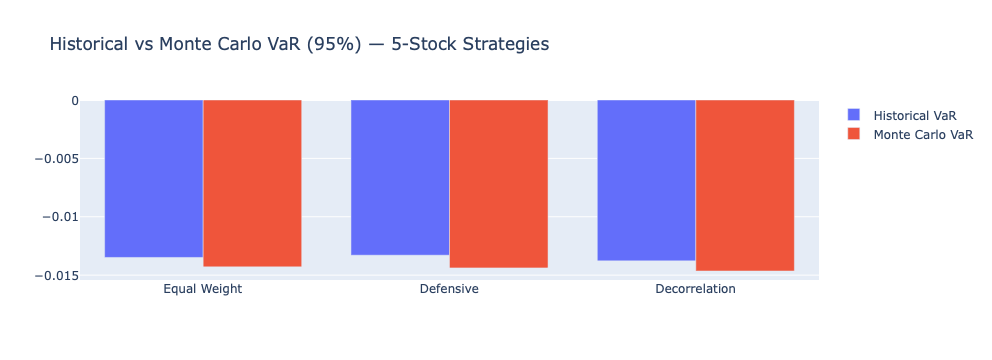

In [5]:
fig_var = go.Figure()
fig_var.add_trace(go.Bar(name='Historical VaR', x=var_comparison.index, y=var_comparison['Historical VaR']))
fig_var.add_trace(go.Bar(name='Monte Carlo VaR', x=var_comparison.index, y=var_comparison['Monte Carlo VaR']))
fig_var.update_layout(barmode='group', title='Historical vs Monte Carlo VaR (95%) — 5-Stock Strategies')
fig_var.show()

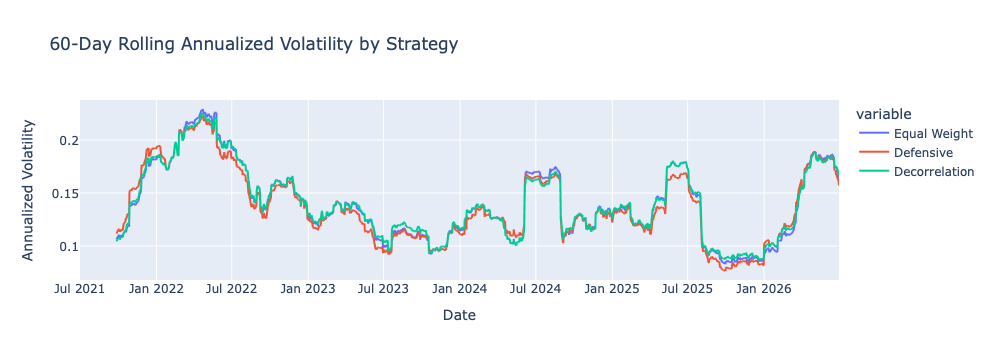

In [6]:
window = 60  # ~3 months of trading days

# Rolling annualized volatility for each portfolio strategy
rolling_vol = portfolio_returns.rolling(window).std() * np.sqrt(252)

fig_rollvol = px.line(
    rolling_vol,
    title=f'{window}-Day Rolling Annualized Volatility by Strategy',
    labels={'value': 'Annualized Volatility', 'Date': 'Date'}
)
fig_rollvol.show()

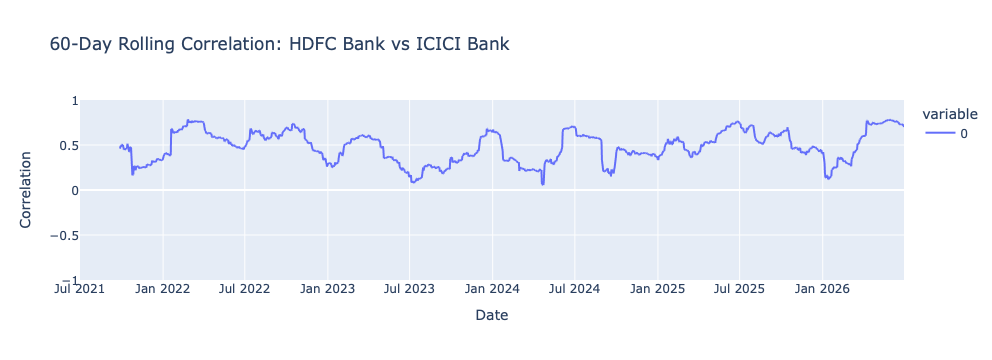

In [7]:
# Rolling correlation: HDFC Bank vs ICICI Bank specifically (your highest-correlation pair)
rolling_corr_hdfc_icici = returns['HDFCBANK.NS'].rolling(window).corr(returns['ICICIBANK.NS'])

fig_rollcorr = px.line(
    rolling_corr_hdfc_icici,
    title=f'{window}-Day Rolling Correlation: HDFC Bank vs ICICI Bank',
    labels={'value': 'Correlation'}
)
fig_rollcorr.update_yaxes(range=[-1, 1])
fig_rollcorr.show()

In [10]:
def risk_report(returns_data, risk_free_rate=0.065, confidence_level=0.95):
    """
    Generic risk report. Works on a single return series or a DataFrame
    with multiple assets/portfolios as columns.
    """
    if isinstance(returns_data, pd.Series):
        returns_data = returns_data.to_frame()

    results = {}
    for col in returns_data.columns:
        r = returns_data[col].dropna()

        ann_return = r.mean() * 252
        ann_vol = r.std() * np.sqrt(252)
        sharpe = (ann_return - risk_free_rate) / ann_vol

        cumulative = (1 + r).cumprod()
        running_max = cumulative.cummax()
        drawdown = (cumulative - running_max) / running_max
        max_dd = drawdown.min()

        var_hist = np.percentile(r, (1 - confidence_level) * 100)

        results[col] = {
            'Annualized Return': ann_return,
            'Annualized Volatility': ann_vol,
            'Sharpe Ratio': sharpe,
            'Max Drawdown': max_dd,
            f'Historical VaR ({int(confidence_level*100)}%)': var_hist
        }

    return pd.DataFrame(results).T

In [11]:
stress_report = risk_report(stress_portfolio_returns)
print(stress_report.round(4))

               Annualized Return  Annualized Volatility  Sharpe Ratio  \
Equal Weight             -0.4299                 0.5956       -0.8309   
Defensive                -0.4835                 0.5779       -0.9491   
Decorrelation            -0.4165                 0.5821       -0.8271   

               Max Drawdown  Historical VaR (95%)  
Equal Weight        -0.3734               -0.0633  
Defensive           -0.3638               -0.0589  
Decorrelation       -0.3637               -0.0619  


In [12]:
stress_start = '2020-02-01'
stress_end = '2020-04-30'

stress_data = yf.download(tickers, start=stress_start, end=stress_end)
stress_prices = stress_data['Close'].dropna()
stress_returns = stress_prices.pct_change().dropna()

# Apply the SAME weights from your 5-year-period optimization to the stress window
stress_portfolio_returns = pd.DataFrame({
    'Equal Weight': stress_returns[tickers] @ weights_equal,
    'Defensive': stress_returns[tickers] @ weights_defensive,
    'Decorrelation': stress_returns[tickers] @ weights_decorr
})

stress_report = risk_report(stress_portfolio_returns)
print(stress_report.round(4))

[*********************100%***********************]  5 of 5 completed

               Annualized Return  Annualized Volatility  Sharpe Ratio  \
Equal Weight             -0.4299                 0.5956       -0.8309   
Defensive                -0.4835                 0.5779       -0.9491   
Decorrelation            -0.4165                 0.5821       -0.8271   

               Max Drawdown  Historical VaR (95%)  
Equal Weight        -0.3734               -0.0633  
Defensive           -0.3638               -0.0589  
Decorrelation       -0.3637               -0.0619  


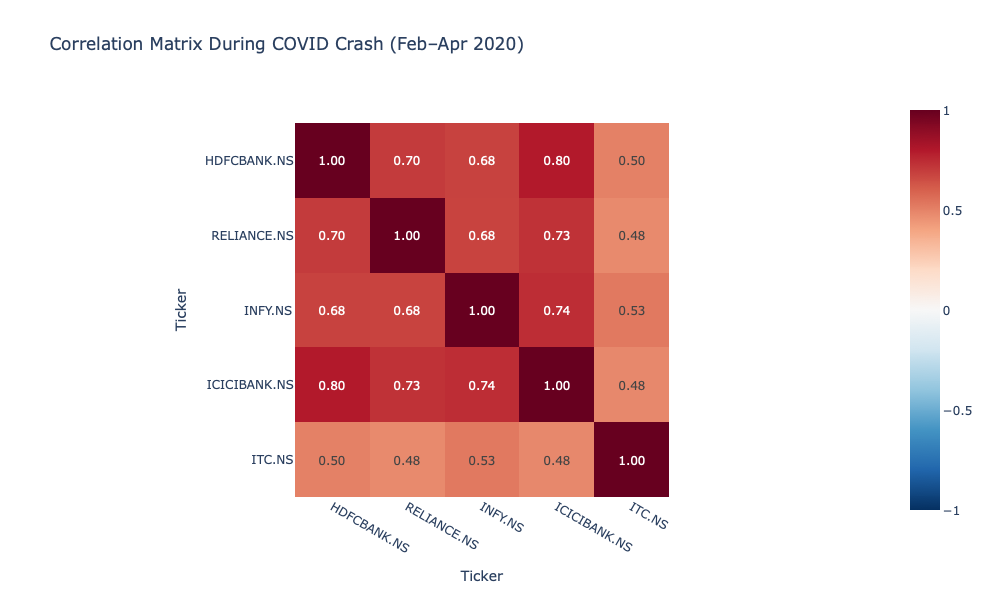

In [13]:
stress_corr = stress_returns[tickers].corr()

fig_stress_heatmap = px.imshow(
    stress_corr, text_auto='.2f', color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1, title='Correlation Matrix During COVID Crash (Feb–Apr 2020)'
)
fig_stress_heatmap.update_layout(width=600, height=600)
fig_stress_heatmap.show()